# Predicción de Deserción de Empleados (Employee Attrition)
## Descripción General
Este notebook desarrolla un modelo predictivo de Machine Learning, bajo la metodología CRISP-DM, para anticipar la deserción de empleados (attrition) en empresas del sector IT. Utilizando datos de IBM HR Analytics, el código realiza un análisis exploratorio, preprocesamiento (incluyendo el balanceo de clases mediante SMOTE) y entrenamiento de algoritmos de clasificación (Regresión Logística y Random Forest).


## 1. Importación de Librerías y Carga de Datos

In [1]:
# Instalación y Carga de Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y Preprocesamiento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Manejo de desbalanceo
from imblearn.over_sampling import SMOTE

# Configuración visual
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Carga y Limpieza de Datos (Ruta Local)
# Definimos el path local que indicaste
path_archivo = "data/WA_Fn-UseC_-HR-Employee-Attrition.csv"

try:
    # Carga del dataset desde el almacenamiento local de Colab
    df = pd.read_csv(path_archivo)
    print("Archivo cargado exitosamente desde el almacenamiento local.")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en {path_archivo}. Por favor, asegúrate de haberlo subido a la carpeta sample_data.")

# 1. Eliminación de variables con varianza cero (Data Quality Issues)
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

# Usamos errors='ignore' por si alguna columna ya fue borrada en una ejecución previa
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 2. Reemplazo directo y forzado de tipo en columnas Attrition & Overtime (str a int)
mapping = {'Yes': 1, 'No': 0}

df['Attrition'] = df['Attrition'].map(mapping).fillna(0).astype(int)
df['OverTime'] = df['OverTime'].map(mapping).fillna(0).astype(int)

#3. Generamos columna que asigne JobLevel (junior/senior)
df['Segmento'] = df['JobLevel'].apply(lambda x: 'Junior/Mid' if x <= 2 else 'Senior/Gerencial')

print(f"Dataset procesado: {df.shape[0]} filas y {df.shape[1]} columnas.")

extremos = pd.concat([df.head(3), df.tail(3)])
display(extremos)

Archivo cargado exitosamente desde el almacenamiento local.
Dataset procesado: 1470 filas y 32 columnas.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Segmento
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,Junior/Mid
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,1,10,3,3,10,7,1,7,Junior/Mid
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,2,0,7,3,3,0,0,0,0,Junior/Mid
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,2,1,6,0,3,6,2,0,3,Junior/Mid
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,4,0,17,3,2,9,6,0,8,Junior/Mid
1469,34,0,Travel_Rarely,628,Research & Development,8,3,Medical,2,Male,...,1,0,6,3,4,4,3,1,2,Junior/Mid


## 2. Análisis Exploratorio de Datos (EDA) y Segmentación

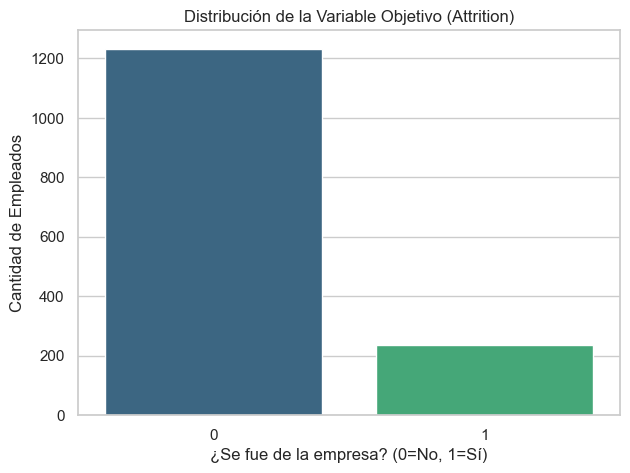

In [3]:
# Gráfico de Desbalance de Clases
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Attrition', data=df, palette='viridis')
plt.title('Distribución de la Variable Objetivo (Attrition)')
plt.xlabel('¿Se fue de la empresa? (0=No, 1=Sí)')
plt.ylabel('Cantidad de Empleados')
plt.show()

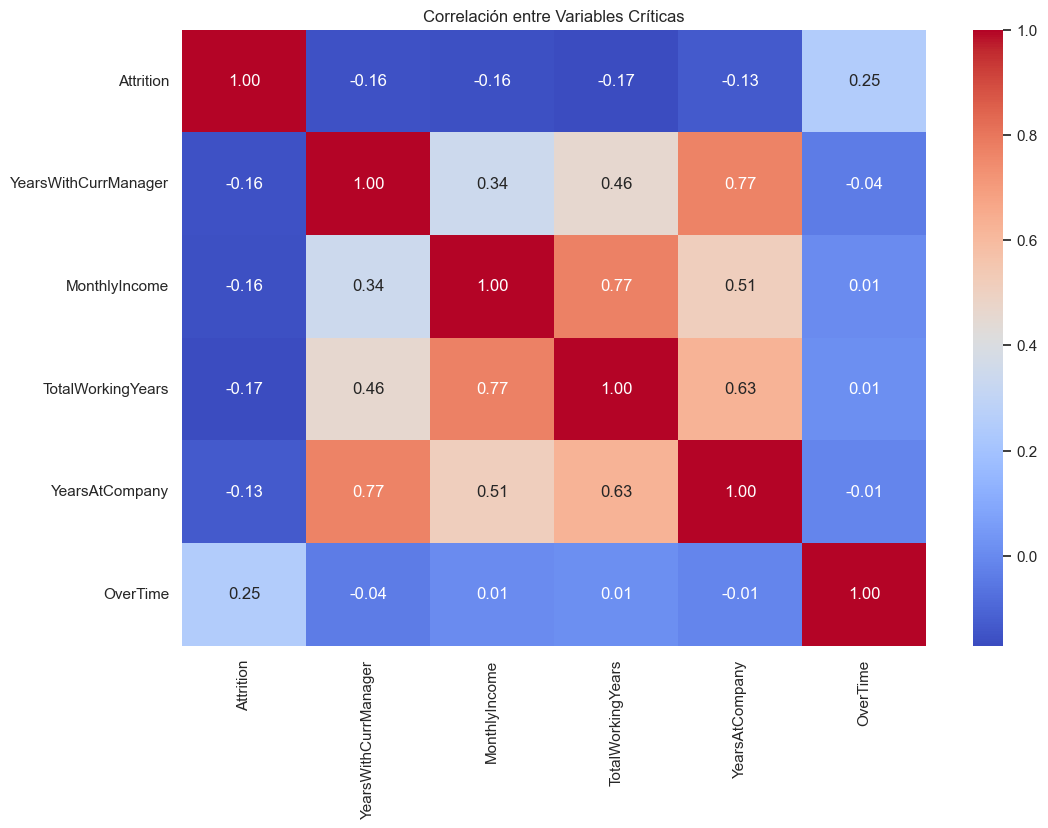

Resultados de correlación para el segmento ATTRITION:
--------------------------------------------------
El valor MÁXIMO es 0.25 y pertenece al segmento: OverTime

podemos notar que el OverTime, es el principal causante de la desercion


In [4]:
# Mapa de Calor de Correlaciones
plt.figure(figsize=(12, 8))
# Seleccionamos solo algunas variables clave
cols_interes = ['Attrition', 'YearsWithCurrManager', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'OverTime']
sns.heatmap(df[cols_interes].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre Variables Críticas')
plt.show()

# 1. Calculamos la matriz de correlación
corr_matrix = df[cols_interes].corr()

# 2. Extraemos la serie de correlaciones específicas de Attrition
# Eliminamos 'Attrition' de la serie para no obtener el 1.00 de la auto-correlación
attrition_corr = corr_matrix['Attrition'].drop('Attrition')

# 3. Identificamos máximos y mínimos
val_max = attrition_corr.max()
seg_max = attrition_corr.idxmax()


# 4. Imprimimos los resultados
print(f"Resultados de correlación para el segmento ATTRITION:")
print("-" * 50)
print(f"El valor MÁXIMO es {val_max:.2f} y pertenece al segmento: {seg_max}")
print(f"\npodemos notar que el OverTime, es el principal causante de la desercion")


Segmento Junior/Semi-Senior (JobLevel 1-2): 1077 filas
Segmento Senior/Gerencial (JobLevel 3-5): 393 filas


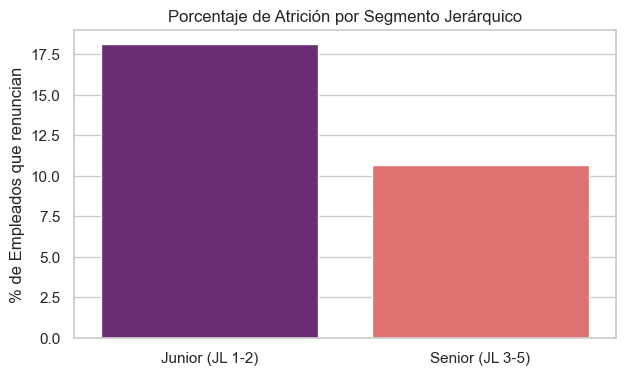

Tasa Atrición Junior: 18.11%
Tasa Atrición Senior: 10.69%

Ingreso promedio Junior: 4133.25069637883
Ingreso promedio Senior: 12996.941475826972


In [5]:
# Análisis de Segmentación OverTime
# Segmentamos por JobLevel (sugerida por el tutor)
df_junior = df[df['JobLevel'] <= 2].copy()
df_senior = df[df['JobLevel'] >= 3].copy()

print(f"Segmento Junior/Semi-Senior (JobLevel 1-2): {len(df_junior)} filas")
print(f"Segmento Senior/Gerencial (JobLevel 3-5): {len(df_senior)} filas")

# Visualización de Atrición por Segmento
plt.figure(figsize=(7, 4))
sns.barplot(x=['Junior (JL 1-2)', 'Senior (JL 3-5)'], y=[df_junior['Attrition'].mean() * 100, df_senior['Attrition'].mean() * 100], palette='magma')
plt.title('Porcentaje de Atrición por Segmento Jerárquico')
plt.ylabel('% de Empleados que renuncian')
plt.show()

# Tasa de atrición por segmento
print(f"Tasa Atrición Junior: {df_junior['Attrition'].mean():.2%}")
print(f"Tasa Atrición Senior: {df_senior['Attrition'].mean():.2%}")

# Comparar variables clave por segmento
print("\nIngreso promedio Junior:", df_junior['MonthlyIncome'].mean())
print("Ingreso promedio Senior:", df_senior['MonthlyIncome'].mean())




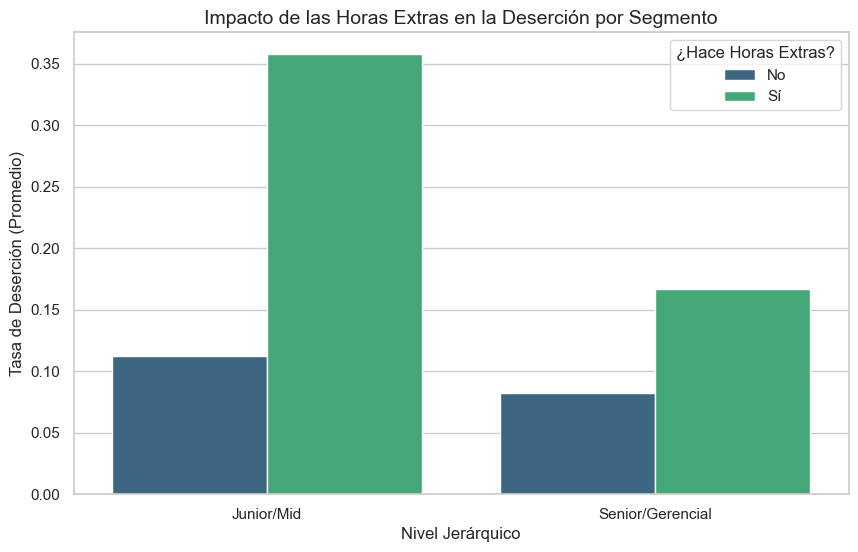

Deserción promedio por OverTime (Segmento Junior):

No hacen Horas Extras (0): 11.23%
Sí hacen Horas Extras (1): 35.76%
----------------------------------------
Deserción promedio por OverTime (Segmento Senior):

No hacen Horas Extras (0): 8.24%
Sí hacen Horas Extras (1): 16.67%


In [6]:

# Creamos el gráfico de barras agrupadas
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Segmento', y='Attrition', hue='OverTime', palette='viridis', ci=None)

# Configuración de etiquetas
plt.title('Impacto de las Horas Extras en la Deserción por Segmento', fontsize=14)
plt.ylabel('Tasa de Deserción (Promedio)')
plt.xlabel('Nivel Jerárquico')
plt.legend(title='¿Hace Horas Extras?', labels=['No', 'Sí'])
plt.show()

# Calculamos el promedio de Attrition agrupado por OverTime solo para Juniors
desercion_ot_junior = df_junior.groupby('OverTime')['Attrition'].mean()

print("Deserción promedio por OverTime (Segmento Junior):")
# Multiplicamos por 100 para verlo como porcentaje
print(f"\nNo hacen Horas Extras (0): {desercion_ot_junior[0]:.2%}")
print(f"Sí hacen Horas Extras (1): {desercion_ot_junior[1]:.2%}")

# Calculamos el promedio de Attrition agrupado por OverTime solo para Juniors
desercion_ot_senior = df_senior.groupby('OverTime')['Attrition'].mean()
print("-" * 40)

print("Deserción promedio por OverTime (Segmento Senior):")
# Multiplicamos por 100 para verlo como porcentaje
print(f"\nNo hacen Horas Extras (0): {desercion_ot_senior[0]:.2%}")
print(f"Sí hacen Horas Extras (1): {desercion_ot_senior[1]:.2%}")



## 3. Preprocesamiento, Modelado y Evaluación

In [7]:
# Preprocesamiento Global y Baseline
# 1. Separar X e y
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# 2. Convertir TODAS las variables categóricas a números (Dummies)
# Esto evita errores de tipos de datos en la Regresión Logística
X = pd.get_dummies(X, drop_first=True)

# 3. Split Estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. Escalamiento Robusto (Manejo de Outliers según tu pre-entrega)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Baseline: Regresión Logística
baseline = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
baseline.fit(X_train_scaled, y_train)

y_pred_base = baseline.predict(X_test_scaled)

print("--- REPORTE BASELINE (REGRESIÓN LOGÍSTICA) ---")
print(classification_report(y_test, y_pred_base))

--- REPORTE BASELINE (REGRESIÓN LOGÍSTICA) ---
              precision    recall  f1-score   support

           0       0.93      0.79      0.86       247
           1       0.39      0.70      0.50        47

    accuracy                           0.78       294
   macro avg       0.66      0.75      0.68       294
weighted avg       0.85      0.78      0.80       294



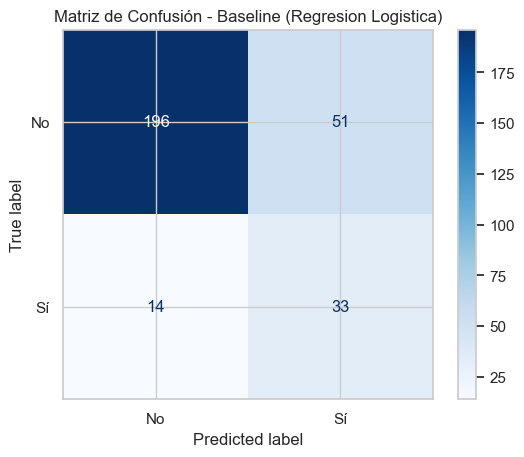

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

# Matriz de confusión Regresion Logistica
cm = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Sí'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Baseline (Regresion Logistica)')
plt.show()

### Nota sobre el Preprocesamiento:
Debido a que la tasa de deserción es baja (clase minoritaria), los datos presentan un sesgo de clase. Para evitar que el modelo ignore a los empleados que renuncian, utilizaremos la técnica SMOTE ($Synthetic$ $Minority$ $Over$-$sampling$ $Technique$).El objetivo es equilibrar el set de entrenamiento para que el algoritmo no solo sea preciso, sino también sensible (Alto Recall) a los factores de riesgo, permitiendo una detección temprana que justifique la inversión en políticas de retención.

In [9]:
# Modelo Final (Random Forest + SMOTE)
# 1. Balanceo con SMOTE sobre el set de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# 2. Entrenamiento de Random Forest
rf_model = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42)
rf_model.fit(X_train_res, y_train_res)

# 3. Predicciones
y_pred_rf = rf_model.predict(X_test_scaled)
y_probs_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("--- RESULTADOS MODELO FINAL (RANDOM FOREST) ---")
print(f"Recall: {recall_score(y_test, y_pred_rf):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.2f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_probs_rf):.2f}")




--- RESULTADOS MODELO FINAL (RANDOM FOREST) ---
Recall: 0.23
F1-Score: 0.30
AUC-ROC: 0.78


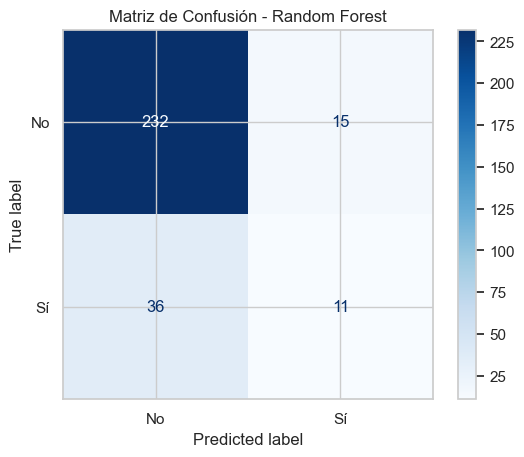

In [10]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Sí'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

## 4. Interpretación del Modelo

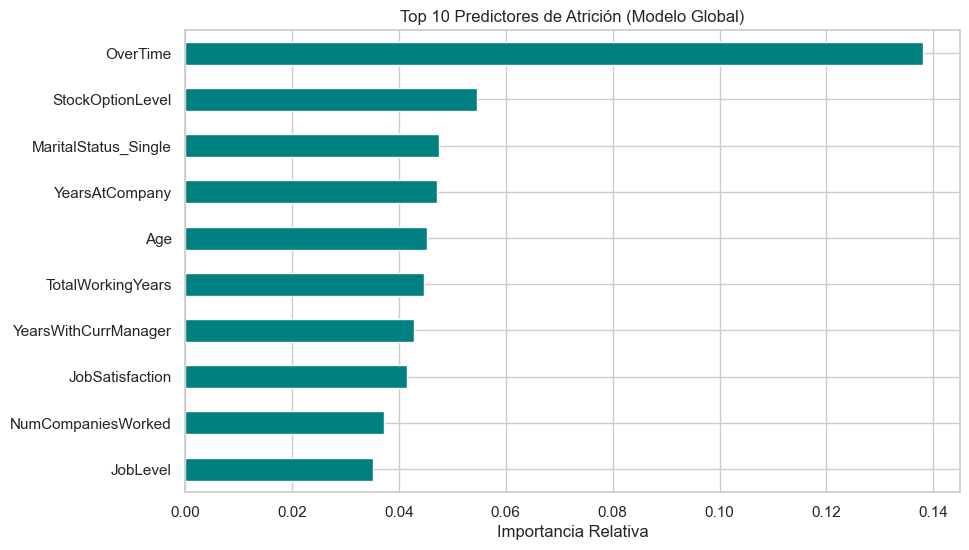

OverTime                0.138075
StockOptionLevel        0.054648
MaritalStatus_Single    0.047505
YearsAtCompany          0.047110
Age                     0.045332
TotalWorkingYears       0.044695
YearsWithCurrManager    0.042821
JobSatisfaction         0.041495
NumCompaniesWorked      0.037331
JobLevel                0.035185
dtype: float64


In [11]:
# Importancia de Variables (Feature Importance)
# Extraer importancia de las variables
importancias = pd.Series(rf_model.feature_importances_, index=X.columns)
top_variables = importancias.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_variables.plot(kind='barh', color='teal')
plt.title('Top 10 Predictores de Atrición (Modelo Global)')
plt.xlabel('Importancia Relativa')
plt.gca().invert_yaxis()
plt.show()

# Ver valores exactos de importancia
importancias_exactas = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importancias_exactas.head(10))


## 5. Conclusiones y Evaluación de Impacto de Negocio

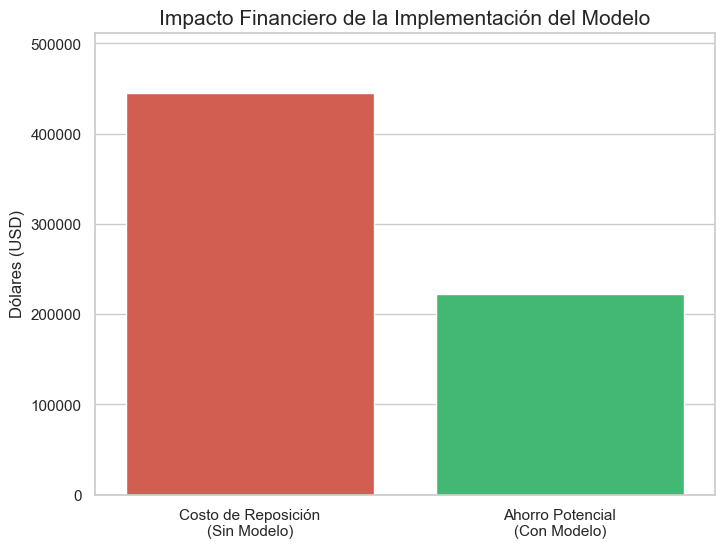

Resultados de Negocio:
- Empleados detectados en riesgo: 26
- Costo de reposición total estimado: $445,164.00 USD
- Ahorro potencial (50% efectividad retención): $222,582.00 USD


In [12]:
#Celda 7: Evaluación de Impacto (KPI de Negocio)
# n = Empleados en riesgo detectados por el modelo
n_riesgo = (y_pred_rf == 1).sum()

# MonthlyIncome promedio de los detectados (usando el índice del test set)
indices_test = y_test.index
ingreso_promedio_riesgo = df.loc[indices_test[y_pred_rf == 1], 'MonthlyIncome'].mean()

# Tu fórmula: Σ (MonthlyIncome * 6)
# Asumiendo una efectividad del 50% en las acciones de RRHH
costo_reposicion_total = n_riesgo * (ingreso_promedio_riesgo * 6)
ahorro_potencial = costo_reposicion_total * 0.5

# Gráfico Final de Impacto Económico

plt.figure(figsize=(8, 6))
sns.barplot(x= ['Costo de Reposición\n(Sin Modelo)', 'Ahorro Potencial\n(Con Modelo)'], y= [costo_reposicion_total, ahorro_potencial], palette= ['#e74c3c', '#2ecc71'])
plt.title('Impacto Financiero de la Implementación del Modelo', fontsize=15)
plt.ylabel('Dólares (USD)')
plt.ylim(0, costo_reposicion_total * 1.15)
plt.show()

print(f"Resultados de Negocio:")
print(f"- Empleados detectados en riesgo: {n_riesgo}")
print(f"- Costo de reposición total estimado: ${costo_reposicion_total:,.2f} USD")
print(f"- Ahorro potencial (50% efectividad retención): ${ahorro_potencial:,.2f} USD")
